<a href="https://colab.research.google.com/github/gobi2001-2006/computer-vision/blob/main/image_classification_using_sift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

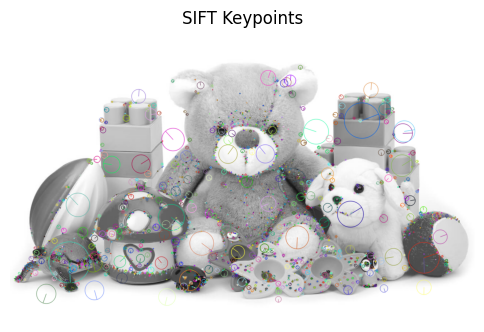

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image (Update the path with your image)
image_path = "image.png"  # Change this to your actual image
image = cv2.imread(image_path)

# Check if the image loaded correctly
if image is None:
    raise FileNotFoundError("Image not found! Check the file path.")

# Convert to grayscale
gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# --- SIFT Feature Extraction (Keypoints) ---
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray_img, None)

# Draw keypoints on the image
sift_img = cv2.drawKeypoints(gray_img, keypoints, None,
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display the SIFT keypoints
plt.figure(figsize=(6, 6))
plt.imshow(sift_img, cmap='gray')
plt.title("SIFT Keypoints")
plt.axis("off")
plt.show()


Model Accuracy: 0.4703


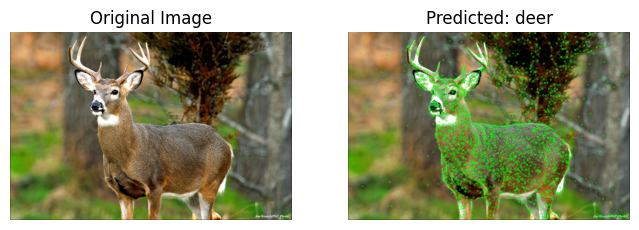

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

# CIFAR-10 class labels
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog",
               "frog", "horse", "ship", "truck"]

# Select only three classes (Cat, Dog, Deer)
selected_classes = {3: "cat", 5: "dog", 4: "deer"}
train_mask = np.isin(y_train, list(selected_classes.keys()))
test_mask = np.isin(y_test, list(selected_classes.keys()))

x_train, y_train = x_train[train_mask], y_train[train_mask]
x_test, y_test = x_test[test_mask], y_test[test_mask]

# Convert labels to class names
y_train = np.array([selected_classes[label] for label in y_train])
y_test = np.array([selected_classes[label] for label in y_test])

# Check if SIFT is available
if not hasattr(cv2, 'SIFT_create'):
    raise ValueError("OpenCV SIFT is not available. Install OpenCV with contrib modules.")

sift = cv2.SIFT_create()

# Function to extract features (SIFT, HOG, GLOH)
def extract_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Resize image for consistency
    resized = cv2.resize(gray, (128, 128))

    # 1️⃣ **Extract SIFT features**
    keypoints, descriptors = sift.detectAndCompute(resized, None)
    sift_feat = np.mean(descriptors, axis=0) if descriptors is not None else np.zeros((128,))

    # 2️⃣ **Extract HOG features**
    hog_feat = hog(resized, pixels_per_cell=(8, 8), cells_per_block=(2, 2),
                   orientations=9, visualize=False)

    # 3️⃣ **Extract GLOH features (variance of descriptors)**
    gloh_feat = np.var(descriptors, axis=0) if descriptors is not None else np.zeros((128,))

    # Combine all features
    features = np.hstack((sift_feat, hog_feat, gloh_feat))

    return features

# Extract features for all images
X_train_features = np.array([extract_features(img) for img in x_train])
X_test_features = np.array([extract_features(img) for img in x_test])

# Apply PCA to reduce dimensions
pca = PCA(n_components=100)  # Reduce to 100 features
X_train_features = pca.fit_transform(X_train_features)
X_test_features = pca.transform(X_test_features)

# Standardize features
scaler = StandardScaler()
X_train_features = scaler.fit_transform(X_train_features)
X_test_features = scaler.transform(X_test_features)

# Train SVM classifier
svm_model = SVC(kernel="linear", C=1.0, random_state=42)
svm_model.fit(X_train_features, y_train)

# Evaluate model
y_pred = svm_model.predict(X_test_features)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Function to classify a new image and show keypoints
def classify_and_visualize(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image, (32, 32))

    # Extract features
    features = extract_features(image_resized).reshape(1, -1)
    features = pca.transform(features)
    features = scaler.transform(features)

    # Predict class
    pred_label = svm_model.predict(features)[0]

    # Show SIFT keypoints
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    keypoints, _ = sift.detectAndCompute(gray, None)
    image_with_keypoints = cv2.drawKeypoints(image, keypoints, None, color=(0, 255, 0))

    # Display the image
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    plt.imshow(image_with_keypoints)
    plt.axis("off")
    plt.title(f"Predicted: {pred_label}")

    plt.show()

# Test with an image
test_image_path = "img2.jpg"  # Change this to a real image path
classify_and_visualize(test_image_path)


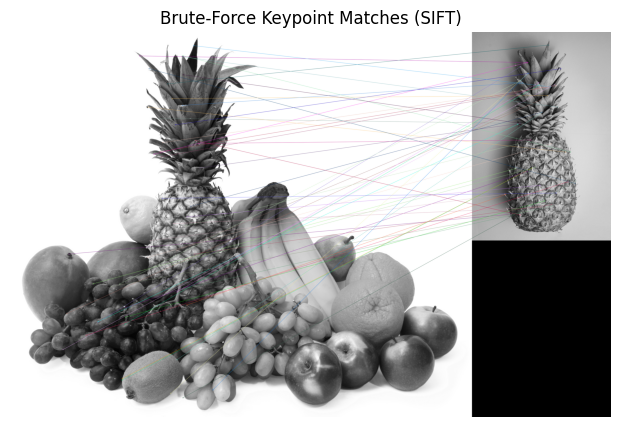

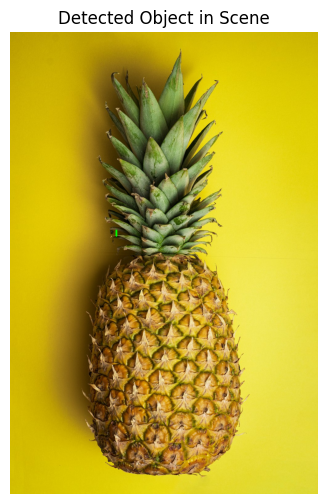

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

object_img = cv2.imread("fruit.jpg", cv2.IMREAD_GRAYSCALE)
scene_img = cv2.imread("pa.jpg", cv2.IMREAD_GRAYSCALE)
scene_img_bgr = cv2.imread("pa.jpg")

if object_img is None or scene_img is None:
    raise ValueError("Error loading images. Check the file paths!")
sift = cv2.SIFT_create()

keypoints_obj, descriptors_obj = sift.detectAndCompute(object_img, None)
keypoints_scene, descriptors_scene = sift.detectAndCompute(scene_img, None)

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

matches = bf.knnMatch(descriptors_obj, descriptors_scene, k=2)

good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]

match_img = cv2.drawMatchesKnn(object_img, keypoints_obj, scene_img, keypoints_scene,
                               [good_matches[:50]], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Show the keypoint matches
plt.figure(figsize=(10, 5))
plt.imshow(match_img)
plt.axis("off")
plt.title("Brute-Force Keypoint Matches (SIFT)")

plt.show()

if len(good_matches) > 10:

    src_pts = np.float32([keypoints_obj[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([keypoints_scene[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    matrix, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    h, w = object_img.shape
    obj_corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    scene_corners = cv2.perspectiveTransform(obj_corners, matrix)

    cv2.polylines(scene_img_bgr, [np.int32(scene_corners)], True, (0, 255, 0), 3, cv2.LINE_AA)

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(scene_img_bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Detected Object in Scene")
    plt.show()

else:
    print("Not enough matches found!")